# Phase 1: Environment Setup and Image Processing Utilities

**Objective:** To establish a robust computer vision pipeline for isolating signatures from noisy backgrounds and to determine the baseline Cosine Similarity threshold using a pre-trained ResNet18 model.

This section initializes the necessary libraries, ensures directory structures exist, and defines helper functions for image visualization.

In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed/asli_master', exist_ok=True)

def display_image(title, img, target_width=800):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if len(img.shape) == 3 else img
    plt.figure(figsize=(10, 5))
    plt.title(title)
    plt.imshow(rgb, cmap='gray' if len(img.shape) == 2 else None)
    plt.axis('off')
    plt.show()

print("Environment setup complete. Libraries loaded successfully.")

Environment setup complete. Libraries loaded successfully.


### 1. Deep Learning Backbone Initialization

We load a pre-trained ResNet18 model to serve as the baseline feature extractor. By detaching the final classification layer, the model is repurposed to output a 512-dimensional continuous feature vector (Signature DNA) which will be used to measure structural similarities.

In [2]:
weights = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=weights)
resnet = torch.nn.Sequential(*(list(resnet.children())[:-1]))
resnet.eval()

preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("ResNet18 feature extractor initialized.")

ResNet18 feature extractor initialized.


### 2. Feature Extraction Pipeline

This core function processes an input image path through our computer vision pipeline. It applies adaptive Gaussian thresholding and contour detection to aggressively isolate pen strokes from varied paper textures. The cropped region is then padded and passed through the ResNet18 backbone to generate the feature vector.

In [3]:
def extract_dna_from_path(file_path):
    image = cv2.imread(file_path)
    if image is None: return torch.zeros(512)
        
    # Preprocessing: Grayscale & Adaptive Thresholding
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                    cv2.THRESH_BINARY_INV, 11, 2)
    
    # Contour detection and bounding box extraction with padding
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        pad = 15
        x_p, y_p = max(0, x-pad), max(0, y-pad)
        w_p, h_p = min(image.shape[1]-x_p, w+(pad*2)), min(image.shape[0]-y_p, h+(pad*2))
        cropped = image[y_p:y_p+h_p, x_p:x_p+w_p]
    else:
        cropped = image

    # Feature extraction via ResNet18
    sig_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
    input_tensor = preprocess(sig_rgb).unsqueeze(0)
    with torch.no_grad():
        dna = resnet(input_tensor).squeeze()
    return dna

print("Function 'extract_dna_from_path' is ready.")

Function 'extract_dna_from_path' is ready.


### 3. Automated Signature Harvesting

To build our ground-truth dataset, we apply the aforementioned contour detection logic to extract individual signatures from a raw, multi-signature scanned document. Dimensional filters are applied to reject artifacts, and the valid signatures are saved to the master directory.

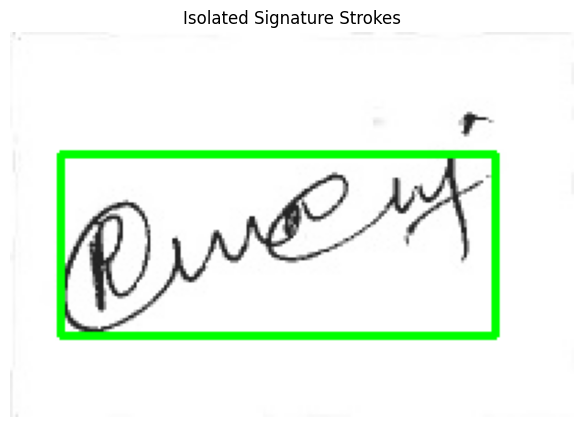

Signature strokes detected: 1 contours.


In [4]:
# Test computer vision preprocessing on genuine signature specimen
image_path = '../extract/001/original_1_1.jpg'
image = cv2.imread(image_path)

if image is not None:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    binary = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2
    )
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    image_with_box = image.copy()
    count = 0
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if cv2.contourArea(cnt) > 200:
            count += 1
            cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)
    display_image('Isolated Signature Strokes', image_with_box)
    print(f'Signature strokes detected: {count} contours.')
else:
    print(f'Could not load {image_path}')

### 4. Forensic Baseline Audit and Threshold Calibration

We evaluate the baseline model's performance by calculating the **Cosine Similarity** and **Cosine Distance** ($d = 1.0 - \text{cosine\_similarity}$) between a master genuine signature, genuine variations, and skilled forgeries from the same signer. We also measure the initial **Triplet Separation Margin** ($d(Anchor, Negative) - d(Anchor, Positive)$). This baseline highlights why metric learning with Triplet Loss is essential to separate skilled forgeries.

In [5]:
# Load genuine signatures for Signer 1 and skilled forgeries from extract/
asli_files = sorted(glob.glob('../extract/001/original_1_*.jpg'))
forgery_files = sorted(glob.glob('../extract/001_forg/forgeries_1_*.jpg'))

results = []
anchor_dna = extract_dna_from_path(asli_files[0])
anchor_dna_norm = F.normalize(anchor_dna.unsqueeze(0), p=2, dim=1)

# Compare Genuine vs. Genuine (Positive Pairs)
gen_distances = []
for i in range(1, len(asli_files)):
    test_dna = extract_dna_from_path(asli_files[i])
    test_dna_norm = F.normalize(test_dna.unsqueeze(0), p=2, dim=1)
    sim = F.cosine_similarity(anchor_dna_norm, test_dna_norm).item()
    dist = 1.0 - sim
    gen_distances.append(dist)
    results.append({'Type': 'Genuine vs Genuine (Pos)', 'Similarity': sim, 'Distance': dist})

# Compare Genuine vs. Forged (Hard Negative Pairs)
forg_distances = []
for f in forgery_files:
    test_dna = extract_dna_from_path(f)
    test_dna_norm = F.normalize(test_dna.unsqueeze(0), p=2, dim=1)
    sim = F.cosine_similarity(anchor_dna_norm, test_dna_norm).item()
    dist = 1.0 - sim
    forg_distances.append(dist)
    results.append({'Type': 'Genuine vs Forged (Neg)', 'Similarity': sim, 'Distance': dist})

df = pd.DataFrame(results)
print('\nFORENSIC BASELINE AUDIT SUMMARY (Cosine Similarity & Distance):')
print(df.groupby('Type')[['Similarity', 'Distance']].describe()[[(c, s) for c in ['Similarity', 'Distance'] for s in ['mean', 'min', 'max']]])

avg_pos_dist = np.mean(gen_distances) if gen_distances else 0.0
avg_neg_dist = np.mean(forg_distances) if forg_distances else 0.0
triplet_gap = avg_neg_dist - avg_pos_dist
print(f'\nBaseline Triplet Margin Gap [d(A, N) - d(A, P)]: {triplet_gap:.4f}')
if triplet_gap < 0.3:
    print('Diagnosis: The baseline model does NOT have sufficient margin separation for skilled forgeries.')
    print('Action: Triplet Loss fine-tuning is REQUIRED to enforce margin separation >= 0.40.')


FORENSIC BASELINE AUDIT SUMMARY (Cosine Similarity & Distance):
                         Similarity                      Distance            \
                               mean       min       max      mean       min   
Type                                                                          
Genuine vs Forged (Neg)    0.892005  0.838713  0.935225  0.107995  0.064775   
Genuine vs Genuine (Pos)   0.909018  0.868758  0.946151  0.090982  0.053849   

                                    
                               max  
Type                                
Genuine vs Forged (Neg)   0.161287  
Genuine vs Genuine (Pos)  0.131242  

Baseline Triplet Margin Gap [d(A, N) - d(A, P)]: 0.0170
Diagnosis: The baseline model does NOT have sufficient margin separation for skilled forgeries.
Action: Triplet Loss fine-tuning is REQUIRED to enforce margin separation >= 0.40.
